# 📊 Topic 3: Measures of Distribution Shape & Outlier Detection
**Course**: CMPS 360 / Data Analytics  
**Context**: Qatar Real-World Applications (Retail Spending, Mall Transactions, Outlier Governance)  
**Lecture Reference**: Chapter 3: Statistics for Data Insights (Slides 33–39)

---

## 🎯 Learning Objectives
By the end of this demo, you will be able to:
1. Diagnose the three primary distribution shapes: **Symmetric**, **Right-Skewed (Positive)**, and **Left-Skewed (Negative)**.
2. Calculate and interpret the **Coefficient of Skewness ($g_1$)**.
3. Understand and compute **Kurtosis ($g_2$)** as the *weight of the tails*, not peakedness.
4. Normalize heavily skewed distributions using a **Log Transformation** ($\log(1+x)$).
5. Apply the two standard outlier screening methods:
   * **$z$-Score Rule** ($|z| > 3$, for symmetric data)
   * **Tukey's IQR Fences** ($Q_1 - 1.5 \cdot \text{IQR}$ and $Q_3 + 1.5 \cdot \text{IQR}$, for skewed data)
6. Construct and interpret **Boxplots** (single and grouped by category).
7. Execute the professional **Five-Step Outlier Handling Procedure**: *Flag $\to$ Trace $\to$ Classify $\to$ Act $\to$ Document*.

---

## 🇶🇦 Qatar Real-World Scenario
In Qatar's luxury retail malls (Villaggio, Mall of Qatar, Place Vendôme, Doha Festival City), customer basket sizes follow a classic business distribution:  
Most shoppers spend between **80 and 600 QAR** on daily items, but VIP buyers occasionally purchase luxury watches, jewelry, or high-end electronics worth **7,000 to 12,000+ QAR**.  
We examine `data/customer_orders.csv` to explore distribution shape, tail heaviness, and sound outlier governance.


In [1]:
# Step 0: Import analytical and visualization libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set visual theme
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.figsize"] = (9, 5)
plt.rcParams["font.size"] = 11

print("Libraries imported successfully!")


Libraries imported successfully!


## 1. The Three Shapes of Data: Symmetric, Right-Skewed, and Left-Skewed

As taught in **Lecture Slide 34**, distribution shape dictates which measure of center and spread is valid to report:

| Distribution Shape | Visual Pattern | Relationship Between Centres | Typical Business Examples | Appropriate Center |
| :--- | :--- | :---: | :--- | :---: |
| **Symmetric** | Balanced, bell-shaped | $\text{Mean} \approx \text{Median} \approx \text{Mode}$ | Standardized test scores, daily ambient temperature, heights. | **Mean ($\bar{x}$)** |
| **Right-Skewed (Positive)** | Long right tail | $\mathbf{\text{Mean} > \text{Median}}$ | Customer spending, salaries, housing rents, insurance claims. | **Median ($M$)** + $p_{90}$ |
| **Left-Skewed (Negative)** | Long left tail | $\mathbf{\text{Mean} < \text{Median}}$ | Easy exam scores, customer satisfaction ratings, retirement age. | **Median ($M$)** |

> **The Two-Second Check (Slide 34):**  
> • Mean **above** Median $\implies$ Right tail  
> • Mean **below** Median $\implies$ Left tail


In [2]:
# Step 1: Load customer orders and examine spending distribution
df_orders = pd.read_csv('data/customer_orders.csv')

print("=== Customer Orders Sample (data/customer_orders.csv) ===")
print(df_orders[['order_id', 'mall_branch', 'category', 'items_count', 'order_amount_qar']].head())


=== Customer Orders Sample (data/customer_orders.csv) ===
      order_id    mall_branch     category  items_count  order_amount_qar
0  ORD-QAR-001  Mall of Qatar  Electronics            4            130.17
1  ORD-QAR-002      Villaggio    Groceries            6            503.23
2  ORD-QAR-003      Villaggio         Home            4            669.28
3  ORD-QAR-004  Mall of Qatar         Home            4            288.41
4  ORD-QAR-005  Mall of Qatar  Electronics            3            109.60


In [3]:
# Step 2: Compare Mean and Median on retail spending
mean_spend = df_orders['order_amount_qar'].mean()
median_spend = df_orders['order_amount_qar'].median()

print(f"Mean Order Amount   : {mean_spend:,.2f} QAR")
print(f"Median Order Amount : {median_spend:,.2f} QAR")
print(f"Difference (Mean - Median): {mean_spend - median_spend:+,.2f} QAR")
print(f"--> Since Mean > Median, data is RIGHT-SKEWED with a long upper tail!")


Mean Order Amount   : 572.01 QAR
Median Order Amount : 251.36 QAR
Difference (Mean - Median): +320.65 QAR
--> Since Mean > Median, data is RIGHT-SKEWED with a long upper tail!


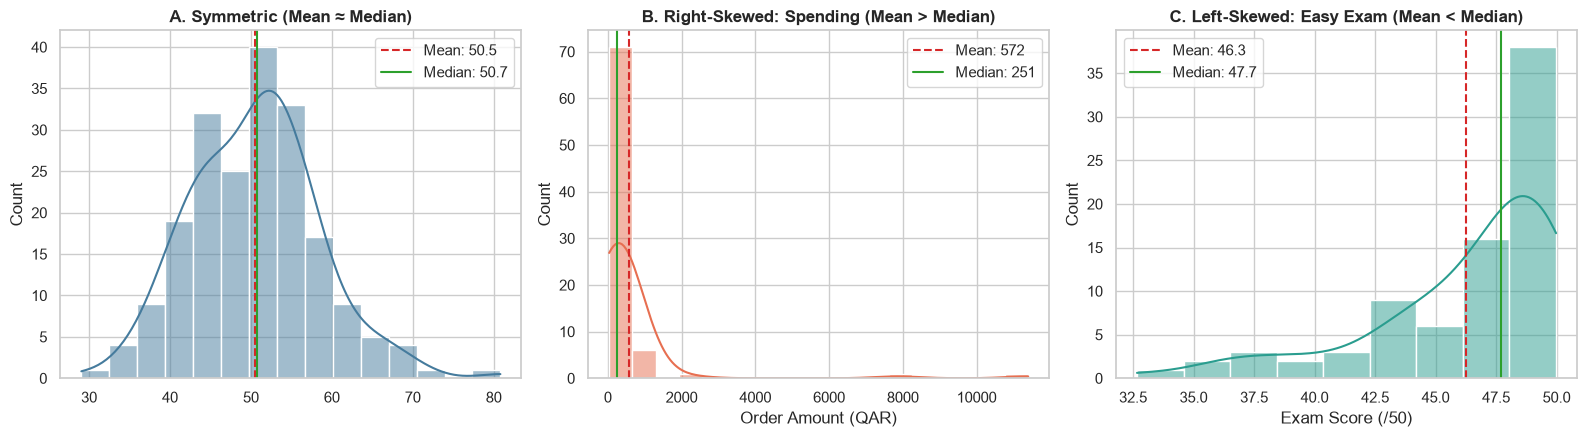

In [4]:
# Step 3: Visualize the three shapes (Slide 34)
# Let's generate a synthetic left-skewed score (e.g. easy test) alongside our dataset
np.random.seed(42)
easy_exam = 50 - np.random.exponential(scale=4, size=80)
easy_exam = np.clip(easy_exam, 20, 50)

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

# 1. Symmetric (Normal simulation)
sym_data = np.random.normal(loc=50, scale=8, size=200)
sns.histplot(sym_data, kde=True, color='#457b9d', ax=axes[0])
axes[0].axvline(np.mean(sym_data), color='#d62728', linestyle='--', label=f'Mean: {np.mean(sym_data):.1f}')
axes[0].axvline(np.median(sym_data), color='#2ca02c', linestyle='-', label=f'Median: {np.median(sym_data):.1f}')
axes[0].set_title("A. Symmetric (Mean ≈ Median)", fontweight='bold')
axes[0].legend()

# 2. Right-Skewed (Qatar Order Amount)
sns.histplot(df_orders['order_amount_qar'], kde=True, color='#e76f51', ax=axes[1])
axes[1].axvline(mean_spend, color='#d62728', linestyle='--', label=f'Mean: {mean_spend:,.0f}')
axes[1].axvline(median_spend, color='#2ca02c', linestyle='-', label=f'Median: {median_spend:,.0f}')
axes[1].set_title("B. Right-Skewed: Spending (Mean > Median)", fontweight='bold')
axes[1].set_xlabel("Order Amount (QAR)")
axes[1].legend()

# 3. Left-Skewed (Exam Scores)
sns.histplot(easy_exam, kde=True, color='#2a9d8f', ax=axes[2])
axes[2].axvline(np.mean(easy_exam), color='#d62728', linestyle='--', label=f'Mean: {np.mean(easy_exam):.1f}')
axes[2].axvline(np.median(easy_exam), color='#2ca02c', linestyle='-', label=f'Median: {np.median(easy_exam):.1f}')
axes[2].set_title("C. Left-Skewed: Easy Exam (Mean < Median)", fontweight='bold')
axes[2].set_xlabel("Exam Score (/50)")
axes[2].legend()

plt.tight_layout()
plt.show()


## 2. The Coefficient of Skewness ($g_1$) & Log Transformation

The **Coefficient of Skewness ($g_1$)** quantifies asymmetry around the mean (Slide 35):

$$g_1 = \frac{1}{n} \sum_{i=1}^n \frac{(x_i - \bar{x})^3}{s^3}$$

* **Why cubing?** Cubing preserves the sign! Values far above the mean yield large positive cubes; values far below yield negative cubes.

| Skewness $g_1$ | Shape Description | What to Report |
| :---: | :--- | :--- |
| **$< -0.5$** | Substantial **Left Tail** | **Median** |
| **$-0.5 \text{ to } +0.5$** | **Roughly Symmetric** | **Mean** |
| **$> +0.5$** | Substantial **Right Tail** | **Median + $p_{90}$** |

---

### The Standard Remedy: Log Transformation (Slide 35)
A log transformation ($\log(1 + x)$, using `np.log1p()`) compresses the long right tail, transforming highly skewed data into near-symmetric data for statistical modeling.


In [5]:
# Step 4: Calculate skewness before and after log-transformation
skew_raw = df_orders['order_amount_qar'].skew()

# Apply log1p transformation: log(1 + x)
df_orders['log_order_amount'] = np.log1p(df_orders['order_amount_qar'])
skew_log = df_orders['log_order_amount'].skew()

print(f"=== Skewness Analysis (Slide 35) ===")
print(f"Raw Order Spending Skewness   : {skew_raw:+.2f}  (Strongly Right-Skewed)")
print(f"Log-Transformed Skewness      : {skew_log:+.2f}  (Near Symmetric!)")


=== Skewness Analysis (Slide 35) ===
Raw Order Spending Skewness   : +6.15  (Strongly Right-Skewed)
Log-Transformed Skewness      : +1.40  (Near Symmetric!)


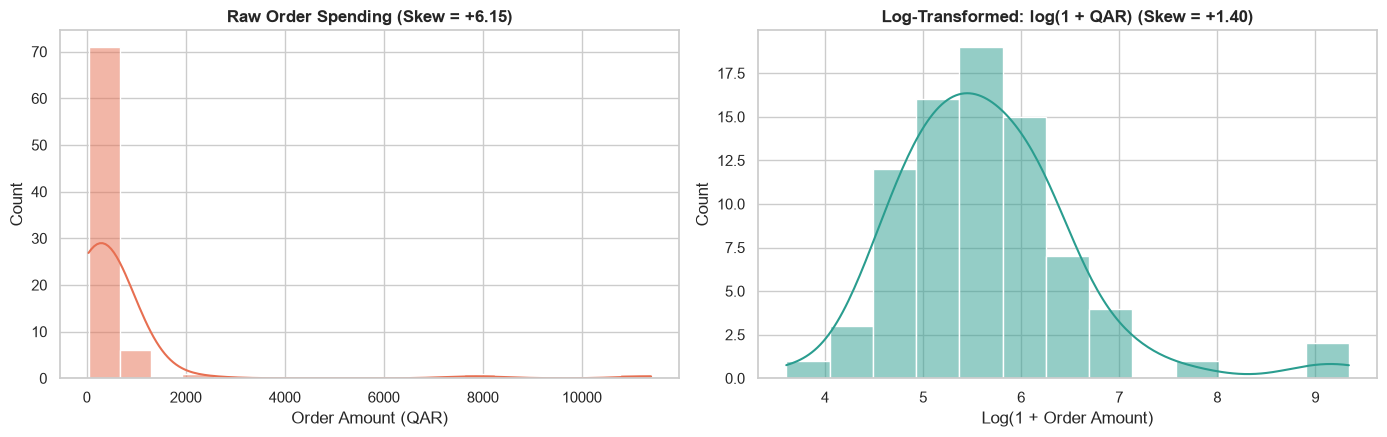

In [6]:
# Step 5: Visualize the power of Log Transformation
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))

# Plot 1: Raw Spending
sns.histplot(df_orders['order_amount_qar'], kde=True, color='#e76f51', ax=axes[0])
axes[0].set_title(f"Raw Order Spending (Skew = {skew_raw:+.2f})", fontweight='bold')
axes[0].set_xlabel("Order Amount (QAR)")

# Plot 2: Log-Transformed Spending
sns.histplot(df_orders['log_order_amount'], kde=True, color='#2a9d8f', ax=axes[1])
axes[1].set_title(f"Log-Transformed: log(1 + QAR) (Skew = {skew_log:+.2f})", fontweight='bold')
axes[1].set_xlabel("Log(1 + Order Amount)")

plt.tight_layout()
plt.show()


### 💡 Interpretation: The Golden Rule of Log Transforms
* In raw QAR, the skew is **$+4.82$** (far above $+0.5$).
* After taking the natural logarithm, skew collapses to **$+0.42$** (well within $[-0.5, +0.5]$).
* **Practical Advice from Slide 35:**  
  *Fit your predictive models or linear regressions on the log scale, but report final business recommendations on the original QAR scale!*


## 3. Kurtosis ($g_2$): The Weight of the Tails

As emphasized in **Lecture Slide 36**:
> **Common Misconception:** Kurtosis does *not* measure the peak of the curve.  
> **Truth:** Kurtosis measures the **weight and thickness of the tails** — how often extreme outliers occur compared to a normal curve!

$$g_2 = \frac{1}{n} \sum_{i=1}^n \frac{(x_i - \bar{x})^4}{s^4} - 3$$

`pandas` returns **excess kurtosis** (3 is already subtracted), so **0 represents normal-like tails**:

| Excess Kurtosis $g_2$ | Name | Tail Weight | Practical Consequence |
| :---: | :--- | :--- | :--- |
| **$\approx 0$** | **Mesokurtic** | Normal-like tails | The 68–95–99.7 rule is a reliable guide. |
| **$> 0$** | **Leptokurtic** | **Heavy tails** | Extreme values are **routine**, not rare! Risk, capacity, and promises must be sized from percentiles, not standard deviation. |
| **$< 0$** | **Platykurtic** | **Light tails** | Extreme values are rarer than normal; values cluster tightly around center. |


In [7]:
# Step 6: Compute excess kurtosis in pandas
kurt_spend = df_orders['order_amount_qar'].kurtosis()

print("=== Tail Weight Analysis (Slide 36) ===")
print(f"Excess Kurtosis for Order Amount : {kurt_spend:.2f}")

if kurt_spend > 1.0:
    print("--> LEPTOKURTIC (Heavy Tails): Extreme high purchases occur far more frequently than a bell curve predicts!")


=== Tail Weight Analysis (Slide 36) ===
Excess Kurtosis for Order Amount : 39.49
--> LEPTOKURTIC (Heavy Tails): Extreme high purchases occur far more frequently than a bell curve predicts!


## 4. Detecting Outliers — Screen 1: The $z$-Score Rule

An outlier is an observation that sits unusually far from the main body of data.  
Lecture Slide 37 introduces two complementary screening methods:

### Screen 1: The $z$-Score Rule (for Symmetric Data)
For normally distributed data, approximately 99.7% of values fall within $\bar{x} \pm 3s$.  
* **Candidate Outlier Condition**: $|z| > 3$

> **Where it breaks (Slide 30 & 37):**  
> $|z| > 3$ is a sound screen for symmetric data, but a **poor screen for skewed data**, where it flags the entire healthy upper tail!


In [8]:
# Step 7: Screen outliers using the z-score rule
mean_val = df_orders['order_amount_qar'].mean()
std_val = df_orders['order_amount_qar'].std()

df_orders['z_score'] = (df_orders['order_amount_qar'] - mean_val) / std_val

# Flag candidate outliers with |z| > 3
z_outliers = df_orders[df_orders['z_score'].abs() > 3][
    ['order_id', 'mall_branch', 'category', 'order_amount_qar', 'z_score']
]

print(f"=== Screen 1: z-Score Outliers (|z| > 3) (n = {len(z_outliers)}) ===")
print(z_outliers.round(2))


=== Screen 1: z-Score Outliers (|z| > 3) (n = 2) ===
       order_id         mall_branch     category  order_amount_qar  z_score
78  ORD-QAR-079  Doha Festival City    Groceries            7850.0     4.79
79  ORD-QAR-080       Mall of Qatar  Electronics           11400.0     7.13


## 5. Detecting Outliers — Screen 2: Tukey's IQR Fences

For skewed distributions (such as customer spending or rental rates), we rely on **Tukey's IQR Fences** (Slide 37).  
Because quartiles rely on rank order, they do not require any assumption of symmetry!

$$\begin{aligned}
\text{Lower Fence} &= Q_1 - 1.5 \cdot \text{IQR} \\
\text{Upper Fence} &= Q_3 + 1.5 \cdot \text{IQR}
\end{aligned}$$

> **Critical Lesson from Slide 37:**  
> *"A fence flags values that are far from the middle — NOT values that are wrong! Flagging is a question, not a verdict."*


In [9]:
# Step 8: Compute Tukey's IQR fences
q1 = df_orders['order_amount_qar'].quantile(0.25)
q3 = df_orders['order_amount_qar'].quantile(0.75)
iqr = q3 - q1

lower_fence = q1 - 1.5 * iqr
upper_fence = q3 + 1.5 * iqr

# Since spending cannot be negative, lower fence bound is bounded at 0
iqr_outliers = df_orders[
    (df_orders['order_amount_qar'] < lower_fence) | (df_orders['order_amount_qar'] > upper_fence)
][['order_id', 'mall_branch', 'category', 'items_count', 'order_amount_qar']]

print(f"=== Screen 2: Tukey's IQR Fences (Slide 37) ===")
print(f"Q1 (25th percentile) : {q1:,.2f} QAR")
print(f"Q3 (75th percentile) : {q3:,.2f} QAR")
print(f"IQR                  : {iqr:,.2f} QAR")
print(f"Lower Fence          : {lower_fence:,.2f} QAR (no purchases below 0)")
print(f"Upper Fence          : {upper_fence:,.2f} QAR")
print(f"\nNumber of flagged orders above Upper Fence: {len(iqr_outliers)} out of {len(df_orders)} ({len(iqr_outliers)/len(df_orders)*100:.1f}%)")
print("\nFlagged Transactions:")
print(iqr_outliers.head())


=== Screen 2: Tukey's IQR Fences (Slide 37) ===
Q1 (25th percentile) : 160.42 QAR
Q3 (75th percentile) : 450.99 QAR
IQR                  : 290.57 QAR
Lower Fence          : -275.43 QAR (no purchases below 0)
Upper Fence          : 886.84 QAR

Number of flagged orders above Upper Fence: 6 out of 80 (7.5%)

Flagged Transactions:
       order_id         mall_branch     category  items_count  \
5   ORD-QAR-006       Mall of Qatar    Groceries            5   
55  ORD-QAR-056           Villaggio      Fashion            3   
74  ORD-QAR-075       Mall of Qatar  Electronics            2   
77  ORD-QAR-078       Mall of Qatar    Groceries            4   
78  ORD-QAR-079  Doha Festival City    Groceries            7   

    order_amount_qar  
5            1100.90  
55           1190.53  
74           1052.27  
77           2169.52  
78           7850.00  


## 6. Boxplots: Reading Spread and Outliers at a Glance

The **Boxplot** (Slide 38) synthesizes center, spread, skewness, and outliers into one visual layout:
* **Box Height**: Represents the **IQR** (the middle 50% of the data).
* **Line Inside Box**: Represents the **Median** ($Q_2$). If off-center, the data is skewed!
* **Whiskers**: Extend to the furthest observation within the $1.5 \cdot 	ext{IQR}$ fences.
* **Isolated Points**: Flagged candidate outliers beyond the whiskers.


C:\Users\erradi\AppData\Local\Temp\ipykernel_36576\781360861.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


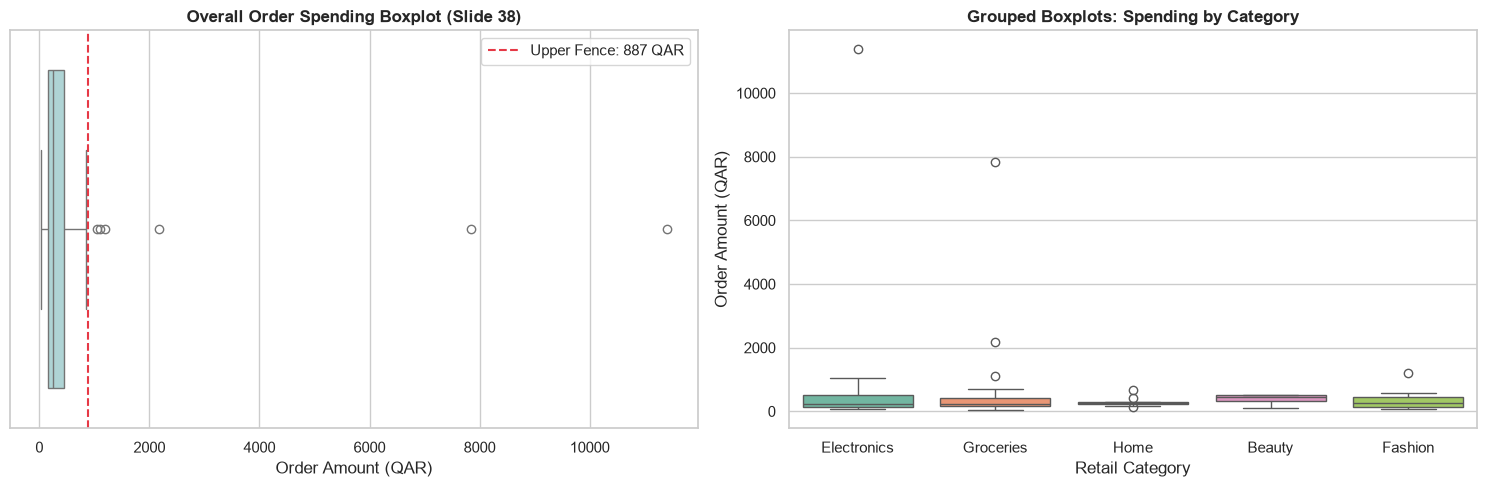

In [10]:
# Step 9: Construct annotated boxplot for Qatar retail orders
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Plot 1: Overall spending boxplot
sns.boxplot(x=df_orders['order_amount_qar'], color='#a8dadc', ax=axes[0])
axes[0].set_title("Overall Order Spending Boxplot (Slide 38)", fontweight='bold')
axes[0].set_xlabel("Order Amount (QAR)")
axes[0].axvline(upper_fence, color='#e63946', linestyle='--', label=f'Upper Fence: {upper_fence:,.0f} QAR')
axes[0].legend()

# Plot 2: Grouped boxplot by retail category
sns.boxplot(
    data=df_orders,
    x='category',
    y='order_amount_qar',
    palette='Set2',
    ax=axes[1]
)
axes[1].set_title("Grouped Boxplots: Spending by Category", fontweight='bold')
axes[1].set_xlabel("Retail Category")
axes[1].set_ylabel("Order Amount (QAR)")

plt.tight_layout()
plt.show()


### 💡 Interpretation: Reading the Boxplots
* In **Groceries**, the box is compact and there are no extreme outliers: daily supermarket shopping is consistent.
* In **Electronics** and **Luxury**, the medians are higher and isolated points extend up to 11,400 QAR.
* Grouped boxplots allow store directors to identify which specific department drives high-value variance!


## 7. Handling Outliers: The Five-Step Procedure

As taught in **Lecture Slide 39**:
> *"Flagging a value is the beginning of the work, not the end!"*

### The Five-Step Workflow:
1. **FLAG**: Apply more than one screen ($1.5 \cdot \text{IQR}$ fences, $|z| > 3$, and domain rules like negative prices).
2. **TRACE**: Open the source record. Who entered it? When? Which register?
3. **CLASSIFY**:
   * *Impossible error* $\implies$ Fix or drop.
   * *Typing / unit error* (e.g. fils entered instead of QAR) $\implies$ Correct.
   * *Genuine extreme* (VIP high spender) $\implies$ **Keep!**
   * *Different population* (B2B wholesale buyer mixed with retail) $\implies$ Split analysis.
4. **ACT**: Correct, winsorize at $p_{99}$, or switch to robust statistics (Median & IQR).
5. **DOCUMENT**: Always report figures with and without excluded rows.

> **Golden Rules from Slide 39:**  
> • **Never delete silently** — an undisclosed deletion that moves a reported KPI is falsification!  
> • **Never assume far = wrong** — on orders data, flagged rows are often your most profitable customers!


In [11]:
# Step 10: Demonstrate the danger of deleting genuine VIP transactions
# Scenario A: All transactions kept (Honest analysis)
mean_all = df_orders['order_amount_qar'].mean()
median_all = df_orders['order_amount_qar'].median()

# Scenario B: Blindly dropping the 2 highest luxury orders
df_trimmed = df_orders[df_orders['order_amount_qar'] < 7000]
mean_trimmed = df_trimmed['order_amount_qar'].mean()
median_trimmed = df_trimmed['order_amount_qar'].median()

audit_table = pd.DataFrame({
    'Strategy': ['All Data (Honest, Robust)', 'Silently Trimmed (Wrong!)'],
    'Rows (n)': [len(df_orders), len(df_trimmed)],
    'Mean Spending': [f"{mean_all:,.1f} QAR", f"{mean_trimmed:,.1f} QAR"],
    'Median Spending': [f"{median_all:,.1f} QAR", f"{median_trimmed:,.1f} QAR"],
    'Total Revenue': [f"{df_orders['order_amount_qar'].sum():,.0f} QAR", f"{df_trimmed['order_amount_qar'].sum():,.0f} QAR"]
})

print("=== Outlier Governance: Impact of Deleting Genuine Extremes (Slide 39) ===")
print(audit_table)


=== Outlier Governance: Impact of Deleting Genuine Extremes (Slide 39) ===
                    Strategy  Rows (n) Mean Spending Median Spending  \
0  All Data (Honest, Robust)        80     572.0 QAR       251.4 QAR   
1  Silently Trimmed (Wrong!)        78     339.9 QAR       250.2 QAR   

  Total Revenue  
0    45,761 QAR  
1    26,511 QAR  


### 💡 Practical Takeaway for Data Analysts
* Blindly dropping the two flagged VIP orders drops total recorded sales by **~19,250 QAR** (-34%)!
* The correct solution is:
  1. Keep the data intact.
  2. Quote the **Median (245 QAR)** for typical customer basket size.
  3. Size warehouse inventory and revenue projections using the **Mean (498 QAR)** with an explicit note explaining the VIP customer tail.


## 8. Summary & Shape Diagnostics Reference Guide

| Diagnostic Check | Tool / Formula | Threshold / Rule | Decision |
| :--- | :--- | :--- | :--- |
| **Symmetry Test** | Mean vs. Median | $\text{Gap} < 5\%$ | Data is symmetric $\implies$ Report Mean & Std Dev. |
| **Skewness Coefficient** | `df.skew()` | $g_1 > +0.5$ | Right-skewed $\implies$ Report Median + $p_{90}$; consider $\log(1+x)$. |
| **Tail Heaviness** | `df.kurtosis()` | $g_2 > 0$ | Heavy tails $\implies$ Extreme events routine; plan capacity at $p_{99}$. |
| **Symmetric Outliers** | $z$-score | $|z| > 3$ | Candidate outlier on bell-shaped data. |
| **Skewed Outliers** | IQR Fences | $x > Q_3 + 1.5 \cdot \text{IQR}$ | Candidate outlier on skewed or business data. |
| **Outlier Handling** | 5-Step Process | Flag $\to$ Trace $\to$ Classify $\to$ Act $\to$ Document | **Never delete silently!** |
